# NHANES Mortality by Liver Fibrosis Status

Comparison of all-cause and cause-group death rates within up to 36 months of baseline
among adults **with vs without baseline liver fibrosis**, using public-use NHANES linked
mortality data across three cohorts (2007-2008, 2011-2012, 2017-2018).

**Fibrosis definitions:**
- FIB-4 index (all cohorts): `(age × AST) / (platelets × √ALT)`
- Liver stiffness measurement via transient elastography (2017-2018 only)

**Matching:** Propensity-score matching on age, sex, BMI, SBP, LDL-C, fasting glucose,
and smoking history.

### Public-use limitations
- Follow-up censored Dec 31, 2019 for all cohorts
- UCOD cause-of-death codes coarsened to 3 groups for 2015–2018 cohorts
- Some death variables perturbed for disclosure avoidance

In [1]:
import os, hashlib, warnings, itertools
import requests
import numpy as np
import pandas as pd
import pyreadstat
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (9, 5)
sns.set_style('whitegrid')

BASE_DIR = os.path.abspath('.')
RAW_NHANES = os.path.join(BASE_DIR, 'data', 'raw', 'nhanes')
RAW_LMF    = os.path.join(BASE_DIR, 'data', 'raw', 'lmf')
for d in [RAW_NHANES, RAW_LMF]:
    os.makedirs(d, exist_ok=True)

## Configuration

In [2]:
NHANES_BASE = 'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public'
LMF_BASE = 'https://ftp.cdc.gov/pub/Health_Statistics/NCHS/datalinkage/linked_mortality'

COHORTS = {
    '2007-2008': {
        'year': 2007, 'suffix': 'E',
        'lmf': f'{LMF_BASE}/NHANES_2007_2008_MORT_2019_PUBLIC.dat',
        'has_elast': False,
    },
    '2011-2012': {
        'year': 2011, 'suffix': 'G',
        'lmf': f'{LMF_BASE}/NHANES_2011_2012_MORT_2019_PUBLIC.dat',
        'has_elast': False,
    },
    '2017-2018': {
        'year': 2017, 'suffix': 'J',
        'lmf': f'{LMF_BASE}/NHANES_2017_2018_MORT_2019_PUBLIC.dat',
        'has_elast': True,
    },
}

# Files to download per cohort: (prefix, list_of_names)
# Each name will have the cycle suffix appended
NHANES_FILES = ['DEMO', 'BIOPRO', 'CBC', 'BMX', 'BPX', 'TRIGLY', 'GLU', 'SMQ']

WINDOW_36 = 36
WINDOW_H  = 24  # harmonized window (2017-2018 max ~37m, ~51% have >=24m)

FIB4_HIGH = 2.67
FIB4_LOW  = 1.30

LSM_CUTPOINTS_A = {'name': 'Castera/EASL', 'sig': 7.1, 'adv': 9.5, 'cir': 12.5}
LSM_CUTPOINTS_B = {'name': 'Eddowes/NAFLD', 'sig': 8.2, 'adv': 9.7, 'cir': 13.6}

UCOD_LABELS = {
    1: 'Heart disease', 2: 'Malignant neoplasms', 3: 'Chronic lower resp.',
    4: 'Accidents', 5: 'Cerebrovascular', 6: "Alzheimer's", 7: 'Diabetes',
    8: 'Influenza/pneumonia', 9: 'Nephritis', 10: 'All other causes',
}

MATCH_COVARIATES = ['AGE', 'FEMALE', 'BMXBMI', 'SBP_MEAN', 'LBDLDL', 'LBXGLU', 'SMOKE_EVER']

## Step 1 — Download data

In [3]:
def download(url, dest):
    """Download with caching."""
    if os.path.exists(dest):
        return dest
    print(f'  GET {url}')
    r = requests.get(url, timeout=180); r.raise_for_status()
    with open(dest, 'wb') as f: f.write(r.content)
    print(f'    -> {os.path.basename(dest)} ({len(r.content):,} bytes, MD5 {hashlib.md5(r.content).hexdigest()})')
    return dest

def read_xpt(path):
    try:
        df, _ = pyreadstat.read_xport(path)
    except UnicodeDecodeError:
        df, _ = pyreadstat.read_xport(path, encoding='latin1')
    return df

def _safe(s, to_type=int):
    s = s.strip().replace('.', '')
    if not s: return None
    try: return to_type(s)
    except ValueError: return None

def parse_lmf(path):
    rows = []
    with open(path) as f:
        for line in f:
            p = line.rstrip('\r\n').ljust(48)
            rows.append({
                'SEQN': _safe(p[0:14]),
                'ELIGSTAT':    _safe(p[14:15]),
                'MORTSTAT':    _safe(p[15:16]),
                'UCOD_LEADING':_safe(p[16:19]),
                'PERMTH_INT':  _safe(p[42:45], float),
                'PERMTH_EXM':  _safe(p[45:48], float),
            })
    return pd.DataFrame(rows)

In [4]:
raw = {}  # raw[cycle] = dict of DataFrames

for cycle, cfg in COHORTS.items():
    print(f'\n=== {cycle} ===')
    yr, sfx = cfg['year'], cfg['suffix']
    cdir = os.path.join(RAW_NHANES, cycle.replace('-','_'))
    os.makedirs(cdir, exist_ok=True)
    d = {}
    
    # NHANES XPT files
    files_to_get = NHANES_FILES.copy()
    if cfg['has_elast']:
        files_to_get.append('LUX')
    for name in files_to_get:
        fname = f'{name}_{sfx}.xpt'
        url = f'{NHANES_BASE}/{yr}/DataFiles/{fname}'
        path = download(url, os.path.join(cdir, fname))
        d[name] = read_xpt(path)
        print(f'  {name}: {len(d[name]):,} rows')
    
    # LMF
    lmf_path = download(cfg['lmf'], os.path.join(RAW_LMF, os.path.basename(cfg['lmf'])))
    d['LMF'] = parse_lmf(lmf_path)
    print(f'  LMF: {len(d["LMF"]):,} rows')
    
    raw[cycle] = d


=== 2007-2008 ===


  DEMO: 10,149 rows
  BIOPRO: 6,917 rows


  CBC: 9,307 rows
  GET https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2007/DataFiles/BMX_E.xpt


    -> BMX_E.xpt (1,800,240 bytes, MD5 de4d6ae686b3c48f1d90fde505103303)
  BMX: 9,762 rows
  GET https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2007/DataFiles/BPX_E.xpt


    -> BPX_E.xpt (2,113,200 bytes, MD5 5a8d2be04520420e62e4375baa51d69e)
  BPX: 9,762 rows
  GET https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2007/DataFiles/TRIGLY_E.xpt


...

    -> GLU_G.xpt (209,200 bytes, MD5 a9cb7c8c50e3d40cd9d28bf423c84791)
  GLU: 3,239 rows
  GET https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2011/DataFiles/SMQ_G.xpt


    -> SMQ_G.xpt (1,946,960 bytes, MD5 d6255f3d78b1aff348ce4167fe2c0b65)
  SMQ: 6,790 rows
  LMF: 9,756 rows

=== 2017-2018 ===


  DEMO: 9,254 rows
  BIOPRO: 6,401 rows
  CBC: 8,366 rows


  BMX: 8,704 rows
  BPX: 8,704 rows
  TRIGLY: 3,036 rows
  GLU: 3,036 rows
  SMQ: 6,724 rows


  LUX: 6,401 rows
  LMF: 9,254 rows


## Step 2 — Clean + merge

In [5]:
def merge_cohort(cycle, raw_d, has_elast):
    """Merge all components for one cohort."""
    # Start with demographics
    df = raw_d['DEMO'].copy()
    
    # Labs: AST, ALT from BIOPRO; Platelets from CBC
    bio = raw_d['BIOPRO'][['SEQN','LBXSASSI','LBXSATSI']].rename(
        columns={'LBXSASSI':'AST','LBXSATSI':'ALT'})
    cbc = raw_d['CBC'][['SEQN','LBXPLTSI']].rename(columns={'LBXPLTSI':'PLATELETS'})
    df = df.merge(bio, on='SEQN', how='left').merge(cbc, on='SEQN', how='left')
    
    # Matching covariates
    bmx = raw_d['BMX'][['SEQN','BMXBMI']]
    df = df.merge(bmx, on='SEQN', how='left')
    
    # Blood pressure: average of available systolic readings
    bpx = raw_d['BPX'][['SEQN'] + [c for c in raw_d['BPX'].columns if c.startswith('BPXSY')]].copy()
    sy_cols = [c for c in bpx.columns if c.startswith('BPXSY')]
    bpx['SBP_MEAN'] = bpx[sy_cols].mean(axis=1)
    df = df.merge(bpx[['SEQN','SBP_MEAN']], on='SEQN', how='left')
    
    # LDL-C (fasting subsample)
    trig_cols = [c for c in raw_d['TRIGLY'].columns if c in ['SEQN','LBDLDL']]
    if 'LBDLDL' in raw_d['TRIGLY'].columns:
        df = df.merge(raw_d['TRIGLY'][trig_cols], on='SEQN', how='left')
    else:
        df['LBDLDL'] = np.nan
    
    # Fasting plasma glucose
    if 'LBXGLU' in raw_d['GLU'].columns:
        df = df.merge(raw_d['GLU'][['SEQN','LBXGLU']], on='SEQN', how='left')
    else:
        df['LBXGLU'] = np.nan
    
    # Smoking: SMQ020=1 means "smoked >=100 cigs in life" -> ever smoker
    smq = raw_d['SMQ'][['SEQN','SMQ020']].copy()
    smq['SMOKE_EVER'] = (smq['SMQ020'] == 1).astype(float)
    smq.loc[~smq['SMQ020'].isin([1,2]), 'SMOKE_EVER'] = np.nan
    df = df.merge(smq[['SEQN','SMOKE_EVER']], on='SEQN', how='left')
    
    # Elastography
    if has_elast and 'LUX' in raw_d:
        lux = raw_d['LUX'][['SEQN','LUXSMED','LUXCAPM']].rename(
            columns={'LUXSMED':'LSM_KPA','LUXCAPM':'CAP_DBM'})
        df = df.merge(lux, on='SEQN', how='left')
    
    # LMF
    df = df.merge(raw_d['LMF'], on='SEQN', how='left')
    
    # Filter: eligible adults
    n0 = len(df)
    df = df[df['ELIGSTAT'] == 1].copy()
    df['AGE'] = df['RIDAGEYR']
    df = df[df['AGE'] >= 18].copy()
    df['FEMALE'] = (df['RIAGENDR'] == 2).astype(float)
    df['CYCLE'] = cycle
    print(f'{cycle}: {n0} -> {len(df)} eligible adults')
    return df

In [6]:
cohorts = {}
for cycle, cfg in COHORTS.items():
    cohorts[cycle] = merge_cohort(cycle, raw[cycle], cfg['has_elast'])

2007-2008: 10149 -> 6219 eligible adults
2011-2012: 9756 -> 5849 eligible adults
2017-2018: 9254 -> 5809 eligible adults


## Step 3 — Define fibrosis status

In [7]:
def compute_fib4(df):
    df = df.copy()
    ok = (df['AST']>0) & (df['ALT']>0) & (df['PLATELETS']>0) & df['AGE'].notna()
    df['FIB4'] = np.nan
    df.loc[ok,'FIB4'] = (df.loc[ok,'AGE']*df.loc[ok,'AST']) / (df.loc[ok,'PLATELETS']*np.sqrt(df.loc[ok,'ALT']))
    
    df['FIB4_CAT'] = pd.Series(np.nan, index=df.index, dtype='object')
    df.loc[df['FIB4'] < FIB4_LOW,  'FIB4_CAT'] = 'low'
    df.loc[(df['FIB4']>=FIB4_LOW) & (df['FIB4']<FIB4_HIGH), 'FIB4_CAT'] = 'indeterminate'
    df.loc[df['FIB4']>=FIB4_HIGH, 'FIB4_CAT'] = 'high'
    
    df['FIBROSIS_FIB4'] = np.nan
    df.loc[df['FIB4_CAT']=='high', 'FIBROSIS_FIB4'] = 1
    df.loc[df['FIB4_CAT']=='low',  'FIBROSIS_FIB4'] = 0
    return df

def compute_lsm(df, cp):
    df = df.copy()
    pfx = cp['name'].replace('/','_').replace(' ','_')
    col_s, col_b = f'LSM_STAGE_{pfx}', f'FIBROSIS_LSM_{pfx}'
    df[col_s] = pd.Series(np.nan, index=df.index, dtype='object')
    df[col_b] = np.nan
    if 'LSM_KPA' not in df.columns: return df
    ok = df['LSM_KPA'].notna()
    df.loc[ok & (df['LSM_KPA']<cp['sig']),  col_s] = 'F0-F1'
    df.loc[ok & (df['LSM_KPA']>=cp['sig']) & (df['LSM_KPA']<cp['adv']), col_s] = 'F2'
    df.loc[ok & (df['LSM_KPA']>=cp['adv']) & (df['LSM_KPA']<cp['cir']), col_s] = 'F3'
    df.loc[ok & (df['LSM_KPA']>=cp['cir']), col_s] = 'F4'
    df.loc[df[col_s].isin(['F3','F4']), col_b] = 1
    df.loc[df[col_s]=='F0-F1', col_b] = 0
    return df

for cycle in cohorts:
    cohorts[cycle] = compute_fib4(cohorts[cycle])
    if COHORTS[cycle]['has_elast']:
        cohorts[cycle] = compute_lsm(cohorts[cycle], LSM_CUTPOINTS_A)
        cohorts[cycle] = compute_lsm(cohorts[cycle], LSM_CUTPOINTS_B)

# Print fibrosis group sizes
for cycle, df in cohorts.items():
    vc = df['FIB4_CAT'].value_counts()
    print(f"\n{cycle} FIB-4: {vc.to_dict()}, missing={df['FIB4'].isna().sum()}")
    if COHORTS[cycle]['has_elast']:
        for cp in [LSM_CUTPOINTS_A, LSM_CUTPOINTS_B]:
            pfx = cp['name'].replace('/','_').replace(' ','_')
            col = f'FIBROSIS_LSM_{pfx}'
            print(f"  LSM {cp['name']}: fib+={int((df[col]==1).sum())}, fib-={int((df[col]==0).sum())}")


2007-2008 FIB-4: {'low': 3982, 'indeterminate': 1391, 'high': 172}, missing=674

2011-2012 FIB-4: {'low': 3523, 'indeterminate': 1399, 'high': 215}, missing=712

2017-2018 FIB-4: {'low': 3573, 'indeterminate': 1342, 'high': 189}, missing=705
  LSM Castera/EASL: fib+=386, fib-=4274
  LSM Eddowes/NAFLD: fib+=370, fib-=4536


## Step 4 — Outcomes: death within window + cause groups

In [8]:
def add_outcomes(df, window):
    w = f'_{window}m'
    df[f'FU{w}']      = df['PERMTH_EXM'].clip(upper=window)
    df[f'PY{w}']      = df[f'FU{w}'] / 12.0
    df[f'DEATH{w}']   = ((df['MORTSTAT']==1) & (df['PERMTH_EXM']<=window)).astype(int)
    for code in UCOD_LABELS:
        df[f'D_UCOD{code}{w}'] = ((df[f'DEATH{w}']==1) & (df['UCOD_LEADING']==code)).astype(int)
    return df

for cycle, df in cohorts.items():
    df = add_outcomes(df, WINDOW_H)
    if cycle != '2017-2018':
        df = add_outcomes(df, WINDOW_36)
    cohorts[cycle] = df

# Quick check
for cycle, df in cohorts.items():
    d24 = df['DEATH_24m'].sum()
    pct = (df['PERMTH_EXM']>=24).mean()*100
    msg = f'{cycle}: {len(df):,} adults, {d24} deaths in 24m, {pct:.0f}% with >=24m FU'
    if cycle != '2017-2018':
        d36 = df['DEATH_36m'].sum()
        msg += f', {d36} deaths in 36m'
    print(msg)

2007-2008: 6,219 adults, 151 deaths in 24m, 94% with >=24m FU, 236 deaths in 36m
2011-2012: 5,849 adults, 111 deaths in 24m, 94% with >=24m FU, 180 deaths in 36m
2017-2018: 5,809 adults, 113 deaths in 24m, 48% with >=24m FU


## Step 5a — Cohort descriptive cards

In [9]:
cards = []
for cycle, df in cohorts.items():
    for window in ([WINDOW_H, WINDOW_36] if cycle != '2017-2018' else [WINDOW_H]):
        w = f'_{window}m'
        iqr = df['PERMTH_EXM'].quantile([.25,.75])
        row = {
            'Cycle': cycle, 'Window (m)': window,
            'N adults': len(df),
            'N FIB4 valid': int(df['FIB4'].notna().sum()),
            'FIB4 high': int((df['FIB4_CAT']=='high').sum()),
            'FIB4 low': int((df['FIB4_CAT']=='low').sum()),
            'FIB4 indet': int((df['FIB4_CAT']=='indeterminate').sum()),
            'N with LSM': int(df['LSM_KPA'].notna().sum()) if 'LSM_KPA' in df.columns else 0,
            'Median FU (m)': df['PERMTH_EXM'].median(),
            'IQR FU': f"{iqr.iloc[0]:.0f}–{iqr.iloc[1]:.0f}",
            '% >= window': f"{(df['PERMTH_EXM']>=window).mean()*100:.1f}",
            'Deaths': int(df[f'DEATH{w}'].sum()),
        }
        cards.append(row)

cards_df = pd.DataFrame(cards)
cards_df

,Cycle,Window (m),N adults,N FIB4 valid,FIB4 high,FIB4 low,FIB4 indet,N with LSM,Median FU (m),IQR FU,% >= window,Deaths
0,2007-2008,24,6219,5545,172,3982,1391,0,141.0,134–148,93.9,151
1,2007-2008,36,6219,5545,172,3982,1391,0,141.0,134–148,92.7,236
2,2011-2012,24,5849,5137,215,3523,1399,0,94.0,89–101,93.9,111
3,2011-2012,36,5849,5137,215,3523,1399,0,94.0,89–101,92.8,180
4,2017-2018,24,5809,5104,189,3573,1342,5091,24.0,17–30,48.2,113


## Step 5b — Unmatched death rates by fibrosis status

In [10]:
def rate_table(df, fib_col, fib_label, window, cycle):
    w = f'_{window}m'
    rows = []
    for val, name in [(1,'Fibrosis+'),(0,'Fibrosis-')]:
        s = df[df[fib_col]==val]
        n = len(s)
        if n == 0: continue
        d = s[f'DEATH{w}'].sum()
        py = s[f'PY{w}'].sum()
        row = {'Cycle':cycle, 'Window':window, 'Def':fib_label,
               'Group':name, 'N':n, 'Deaths':int(d),
               'PY':round(py,1),
               'Risk':round(d/n,4) if n else np.nan,
               'Rate/1000PY':round(d/py*1000,1) if py>0 else np.nan}
        # cause-group
        for code, lab in UCOD_LABELS.items():
            dc = s[f'D_UCOD{code}{w}'].sum()
            row[f'd_{lab}'] = int(dc)
        rows.append(row)
    return pd.DataFrame(rows)

all_rates = []
for cycle, df in cohorts.items():
    windows = [WINDOW_H] + ([WINDOW_36] if cycle != '2017-2018' else [])
    fib_defs = [('FIB4 ≥2.67 vs <1.30', 'FIBROSIS_FIB4')]
    if COHORTS[cycle]['has_elast']:
        for cp in [LSM_CUTPOINTS_A, LSM_CUTPOINTS_B]:
            pfx = cp['name'].replace('/','_').replace(' ','_')
            fib_defs.append((f"LSM {cp['name']}", f'FIBROSIS_LSM_{pfx}'))
    for w in windows:
        for lab, col in fib_defs:
            all_rates.append(rate_table(df, col, lab, w, cycle))

rates_df = pd.concat(all_rates, ignore_index=True)
rates_df[['Cycle','Window','Def','Group','N','Deaths','PY','Risk','Rate/1000PY']]

,Cycle,Window,Def,Group,N,Deaths,PY,Risk,Rate/1000PY
0,2007-2008,24,FIB4 ≥2.67 vs <1.30,Fibrosis+,172,22,322.2,0.1279,68.3
1,2007-2008,24,FIB4 ≥2.67 vs <1.30,Fibrosis-,3982,39,7928.4,0.0098,4.9
2,2007-2008,36,FIB4 ≥2.67 vs <1.30,Fibrosis+,172,31,469.0,0.1802,66.1
3,2007-2008,36,FIB4 ≥2.67 vs <1.30,Fibrosis-,3982,56,11861.6,0.0141,4.7
4,2011-2012,24,FIB4 ≥2.67 vs <1.30,Fibrosis+,215,23,406.9,0.1070,56.5
5,2011-2012,24,FIB4 ≥2.67 vs <1.30,Fibrosis-,3523,19,7029.8,0.0054,2.7
6,2011-2012,36,FIB4 ≥2.67 vs <1.30,Fibrosis+,215,36,593.1,0.1674,60.7
7,2011-2012,36,FIB4 ≥2.67 vs <1.30,Fibrosis-,3523,38,10525.7,0.0108,3.6
8,2017-2018,24,FIB4 ≥2.67 vs <1.30,Fibrosis+,189,26,300.2,0.1376,86.6
9,2017-2018,24,FIB4 ≥2.67 vs <1.30,Fibrosis-,3573,20,6195.7,0.0056,3.2


## Step 5c — Propensity-score matching

In [11]:
def propensity_match(df, fib_col, covariates, caliper=0.2, ratio=1, random_state=42):
    """
    1:1 nearest-neighbour propensity-score matching without replacement.
    Returns matched DataFrame with a MATCH_ID column.
    """
    sub = df.dropna(subset=[fib_col] + covariates).copy()
    treated  = sub[sub[fib_col]==1]
    control  = sub[sub[fib_col]==0]
    
    if len(treated) < 5 or len(control) < 5:
        print(f'  Too few subjects for matching (treated={len(treated)}, control={len(control)})')
        return pd.DataFrame()
    
    # Fit logistic regression for propensity score
    X = sub[covariates].copy()
    # Standardize continuous covariates for numeric stability
    for c in covariates:
        if sub[c].nunique() > 2:
            X[c] = (X[c] - X[c].mean()) / (X[c].std() + 1e-8)
    y = sub[fib_col].astype(int)
    
    try:
        model = sm.Logit(y, sm.add_constant(X)).fit(disp=0, maxiter=100)
        sub['ps'] = model.predict(sm.add_constant(X))
    except Exception as e:
        print(f'  PS model failed: {e}')
        return pd.DataFrame()
    
    ps_std = sub['ps'].std()
    cal = caliper * ps_std
    
    treated_idx = sub[sub[fib_col]==1].index.tolist()
    control_idx = sub[sub[fib_col]==0].index.tolist()
    
    rng = np.random.default_rng(random_state)
    rng.shuffle(treated_idx)
    
    matched_t, matched_c = [], []
    used = set()
    
    ctrl_ps = sub.loc[control_idx, 'ps'].values
    ctrl_arr = np.array(control_idx)
    
    for t_i in treated_idx:
        ps_t = sub.loc[t_i, 'ps']
        dists = np.abs(ctrl_ps - ps_t)
        # Mask already used
        mask = np.array([c not in used for c in ctrl_arr])
        dists[~mask] = np.inf
        
        best = np.argmin(dists)
        if dists[best] <= cal:
            c_i = ctrl_arr[best]
            matched_t.append(t_i)
            matched_c.append(c_i)
            used.add(c_i)
    
    if not matched_t:
        print('  No matches found within caliper')
        return pd.DataFrame()
    
    # Build matched dataset
    match_ids = list(range(len(matched_t)))
    mt = sub.loc[matched_t].copy()
    mt['MATCH_ID'] = match_ids
    mc = sub.loc[matched_c].copy()
    mc['MATCH_ID'] = match_ids
    matched = pd.concat([mt, mc], ignore_index=True)
    
    print(f'  Matched {len(matched_t)} pairs (of {len(treated_idx)} treated, '
          f'{len(control_idx)} controls); caliper={cal:.4f}')
    return matched

In [12]:
def covariate_balance(df, fib_col, covariates):
    """Compute standardized mean differences."""
    rows = []
    for c in covariates:
        t = df.loc[df[fib_col]==1, c].dropna()
        ctrl = df.loc[df[fib_col]==0, c].dropna()
        if len(t)==0 or len(ctrl)==0:
            rows.append({'Covariate':c, 'Mean(Fib+)':np.nan, 'Mean(Fib-)':np.nan, 'SMD':np.nan})
            continue
        pooled_std = np.sqrt((t.var() + ctrl.var()) / 2)
        smd = (t.mean() - ctrl.mean()) / pooled_std if pooled_std > 0 else 0
        rows.append({'Covariate':c, 'Mean(Fib+)':round(t.mean(),2),
                     'Mean(Fib-)':round(ctrl.mean(),2), 'SMD':round(smd,3)})
    return pd.DataFrame(rows)

In [13]:
matched_cohorts = {}  # matched_cohorts[(cycle, fib_def_label)] = matched_df

for cycle, df in cohorts.items():
    fib_defs = [('FIB4 ≥2.67 vs <1.30', 'FIBROSIS_FIB4')]
    if COHORTS[cycle]['has_elast']:
        for cp in [LSM_CUTPOINTS_A, LSM_CUTPOINTS_B]:
            pfx = cp['name'].replace('/','_').replace(' ','_')
            fib_defs.append((f"LSM {cp['name']}", f'FIBROSIS_LSM_{pfx}'))
    
    for fib_label, fib_col in fib_defs:
        print(f'\n--- {cycle} / {fib_label} ---')
        
        # Pre-match balance
        pre = df.dropna(subset=[fib_col]+MATCH_COVARIATES)
        print(f'  Available for matching: {len(pre)} '
              f'(fib+={int((pre[fib_col]==1).sum())}, fib-={int((pre[fib_col]==0).sum())})')
        
        pre_bal = covariate_balance(pre, fib_col, MATCH_COVARIATES)
        print('  Pre-match balance:')
        print(pre_bal.to_string(index=False))
        
        m = propensity_match(df, fib_col, MATCH_COVARIATES)
        if len(m) == 0:
            continue
        
        # Add outcomes to matched
        m = add_outcomes(m, WINDOW_H)
        if cycle != '2017-2018':
            m = add_outcomes(m, WINDOW_36)
        
        matched_cohorts[(cycle, fib_label)] = (m, fib_col)
        
        post_bal = covariate_balance(m, fib_col, MATCH_COVARIATES)
        print('  Post-match balance:')
        print(post_bal.to_string(index=False))


--- 2007-2008 / FIB4 ≥2.67 vs <1.30 ---
  Available for matching: 1742 (fib+=79, fib-=1663)
  Pre-match balance:
 Covariate  Mean(Fib+)  Mean(Fib-)    SMD
       AGE       69.24       43.19  1.914
    FEMALE        0.39        0.53 -0.280
    BMXBMI       27.64       28.96 -0.224
  SBP_MEAN      131.78      119.90  0.621
    LBDLDL       93.86      117.17 -0.694
    LBXGLU      120.47      107.82  0.319
SMOKE_EVER        0.51        0.47  0.077


  Matched 59 pairs (of 79 treated, 1663 controls); caliper=0.0235
  Post-match balance:
 Covariate  Mean(Fib+)  Mean(Fib-)    SMD
       AGE       66.12       66.42 -0.024
    FEMALE        0.41        0.51 -0.203
    BMXBMI       28.06       28.01  0.009
  SBP_MEAN      130.68      136.36 -0.242
    LBDLDL       97.32       96.66  0.021
    LBXGLU      117.81      124.34 -0.163
SMOKE_EVER        0.54        0.44  0.203

--- 2011-2012 / FIB4 ≥2.67 vs <1.30 ---
  Available for matching: 1580 (fib+=100, fib-=1480)


  Pre-match balance:
 Covariate  Mean(Fib+)  Mean(Fib-)    SMD
       AGE       69.63       40.06  2.299
    FEMALE        0.40        0.52 -0.244
    BMXBMI       27.75       28.79 -0.167
  SBP_MEAN      134.52      118.54  0.805
    LBDLDL      101.80      115.12 -0.387
    LBXGLU      116.27      104.39  0.351
SMOKE_EVER        0.58        0.39  0.388
  Matched 65 pairs (of 100 treated, 1480 controls); caliper=0.0317
  Post-match balance:
 Covariate  Mean(Fib+)  Mean(Fib-)    SMD
       AGE       64.72       64.57  0.014
    FEMALE        0.48        0.45  0.061
    BMXBMI       28.17       28.37 -0.035
  SBP_MEAN      132.95      130.41  0.132
    LBDLDL      105.98      104.34  0.042
    LBXGLU      115.82      113.05  0.077
SMOKE_EVER        0.49        0.52 -0.061

--- 2017-2018 / FIB4 ≥2.67 vs <1.30 ---
  Available for matching: 1676 (fib+=87, fib-=1589)
  Pre-match balance:
 Covariate  Mean(Fib+)  Mean(Fib-)    SMD
       AGE       69.61       42.63  1.919
    FEMALE        0.

## Step 5d — Matched death rates

In [14]:
matched_rates = []
for (cycle, fib_label), (mdf, fib_col) in matched_cohorts.items():
    windows = [WINDOW_H] + ([WINDOW_36] if cycle != '2017-2018' else [])
    for w in windows:
        rt = rate_table(mdf, fib_col, f'{fib_label} (matched)', w, cycle)
        matched_rates.append(rt)

if matched_rates:
    mrates_df = pd.concat(matched_rates, ignore_index=True)
    display(mrates_df[['Cycle','Window','Def','Group','N','Deaths','PY','Risk','Rate/1000PY']])

,Cycle,Window,Def,Group,N,Deaths,PY,Risk,Rate/1000PY
0,2007-2008,24,FIB4 ≥2.67 vs <1.30 (matched),Fibrosis+,59,6,112.3,0.1017,53.4
1,2007-2008,24,FIB4 ≥2.67 vs <1.30 (matched),Fibrosis-,59,1,117.4,0.0169,8.5
2,2007-2008,36,FIB4 ≥2.67 vs <1.30 (matched),Fibrosis+,59,10,164.3,0.1695,60.9
3,2007-2008,36,FIB4 ≥2.67 vs <1.30 (matched),Fibrosis-,59,3,174.5,0.0508,17.2
4,2011-2012,24,FIB4 ≥2.67 vs <1.30 (matched),Fibrosis+,65,3,126.1,0.0462,23.8
5,2011-2012,24,FIB4 ≥2.67 vs <1.30 (matched),Fibrosis-,65,2,127.8,0.0308,15.6
6,2011-2012,36,FIB4 ≥2.67 vs <1.30 (matched),Fibrosis+,65,5,187.6,0.0769,26.7
7,2011-2012,36,FIB4 ≥2.67 vs <1.30 (matched),Fibrosis-,65,2,190.8,0.0308,10.5
8,2017-2018,24,FIB4 ≥2.67 vs <1.30 (matched),Fibrosis+,77,7,127.6,0.0909,54.9
9,2017-2018,24,FIB4 ≥2.67 vs <1.30 (matched),Fibrosis-,77,2,132.9,0.0260,15.0


## Step 5e — Effect estimates (matched)

In [15]:
def risk_ratio(df, fib_col, window):
    w = f'_{window}m'
    t = df[df[fib_col]==1]; c = df[df[fib_col]==0]
    n1,n0 = len(t),len(c)
    d1,d0 = t[f'DEATH{w}'].sum(), c[f'DEATH{w}'].sum()
    if n1==0 or n0==0 or d0==0:
        return {'RR':np.nan,'lo':np.nan,'hi':np.nan,'d1':d1,'d0':d0,'n1':n1,'n0':n0}
    r1,r0 = d1/n1, d0/n0
    rr = r1/r0
    se = np.sqrt(1/d1 - 1/n1 + 1/d0 - 1/n0) if d1>0 else np.nan
    lo = np.exp(np.log(rr)-1.96*se) if np.isfinite(se) else np.nan
    hi = np.exp(np.log(rr)+1.96*se) if np.isfinite(se) else np.nan
    return {'RR':round(rr,2),'lo':round(lo,2),'hi':round(hi,2),'d1':int(d1),'d0':int(d0),'n1':n1,'n0':n0}

ee_rows = []
for (cycle, fib_label), (mdf, fib_col) in matched_cohorts.items():
    windows = [WINDOW_H] + ([WINDOW_36] if cycle != '2017-2018' else [])
    for w in windows:
        rr = risk_ratio(mdf, fib_col, w)
        ee_rows.append({'Cycle':cycle,'Window':w,'Def':fib_label,
                        'N matched pairs': rr['n1'],
                        'Deaths(Fib+)':rr['d1'], 'Deaths(Fib-)':rr['d0'],
                        'RR':rr['RR'],'95% CI':f"{rr['lo']}–{rr['hi']}"})

if ee_rows:
    ee_df = pd.DataFrame(ee_rows)
    display(ee_df)

,Cycle,Window,Def,N matched pairs,Deaths(Fib+),Deaths(Fib-),RR,95% CI
0,2007-2008,24,FIB4 ≥2.67 vs <1.30,59,6,1,6.00,0.75–48.32
1,2007-2008,36,FIB4 ≥2.67 vs <1.30,59,10,3,3.33,0.97–11.5
2,2011-2012,24,FIB4 ≥2.67 vs <1.30,65,3,2,1.50,0.26–8.68
3,2011-2012,36,FIB4 ≥2.67 vs <1.30,65,5,2,2.50,0.5–12.42
4,2017-2018,24,FIB4 ≥2.67 vs <1.30,77,7,2,3.50,0.75–16.32
5,2017-2018,24,LSM Castera/EASL,136,4,3,1.33,0.3–5.85
6,2017-2018,24,LSM Eddowes/NAFLD,137,4,0,NaN,nan–nan


## Step 5f — Kaplan-Meier curves

In [16]:
def plot_km(df, fib_col, fib_label, cycle, window, title_extra=''):
    """Plot Kaplan-Meier curves for fibrosis+ vs fibrosis- within the given window."""
    w = f'_{window}m'
    sub = df[df[fib_col].notna()].copy()
    sub['T'] = sub[f'FU{w}']
    sub['E'] = sub[f'DEATH{w}']
    
    fig, ax = plt.subplots(figsize=(7, 5))
    kmf = KaplanMeierFitter()
    
    colors = {1: '#d62728', 0: '#2ca02c'}
    labels = {1: 'Fibrosis+', 0: 'Fibrosis−'}
    
    for val in [0, 1]:
        mask = sub[fib_col] == val
        grp = sub[mask]
        if len(grp) == 0: continue
        kmf.fit(grp['T'], grp['E'], label=f"{labels[val]} (n={len(grp)}, d={int(grp['E'].sum())})")
        kmf.plot_survival_function(ax=ax, color=colors[val], ci_show=True, ci_alpha=0.15)
    
    # Log-rank test
    g1 = sub[sub[fib_col]==1]
    g0 = sub[sub[fib_col]==0]
    if len(g1)>0 and len(g0)>0 and (g1['E'].sum()+g0['E'].sum())>0:
        lr = logrank_test(g1['T'], g0['T'], g1['E'], g0['E'])
        pval = lr.p_value
        pstr = f'p < 0.001' if pval < 0.001 else f'p = {pval:.3f}'
        ax.text(0.98, 0.02, f'Log-rank {pstr}', transform=ax.transAxes,
                ha='right', va='bottom', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.5))
    
    ax.set_xlabel('Months from MEC exam')
    ax.set_ylabel('Survival probability')
    ax.set_title(f'{cycle}: {fib_label}{title_extra}\n(within {window}-month window)')
    ax.set_xlim(0, window)
    ax.set_ylim(bottom=max(0, ax.get_ylim()[0] - 0.02))
    ax.legend(loc='lower left', fontsize=9)
    plt.tight_layout()
    plt.show()

### Unmatched Kaplan-Meier curves

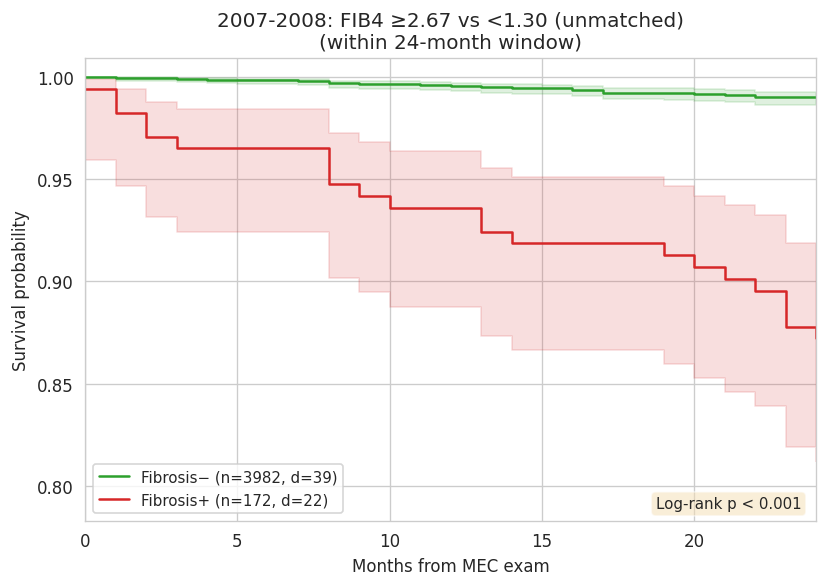

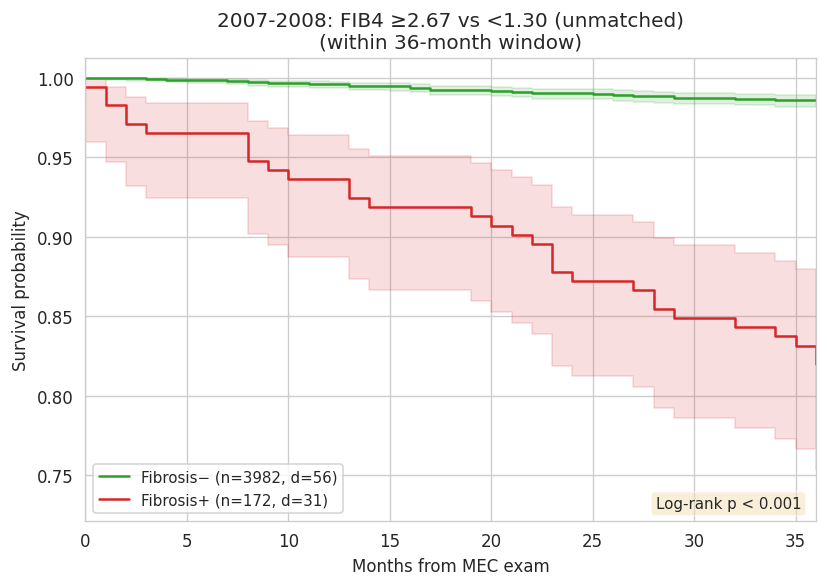

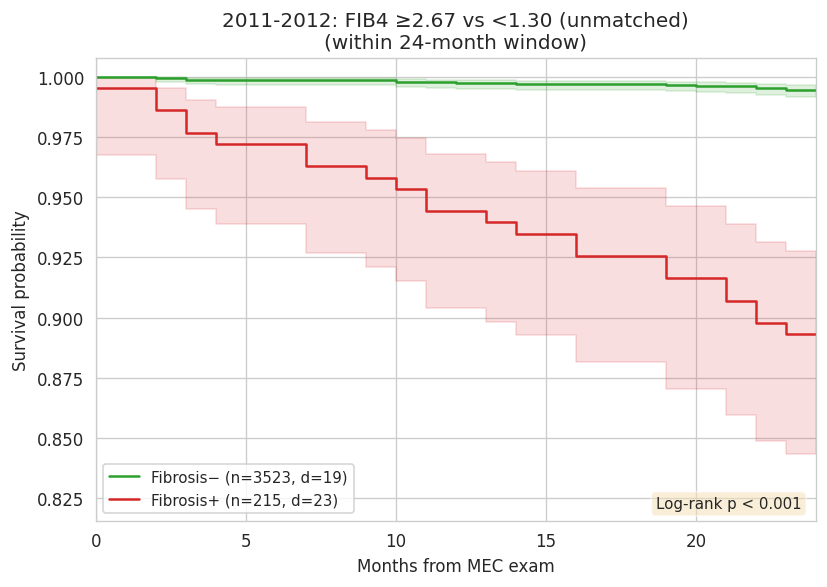

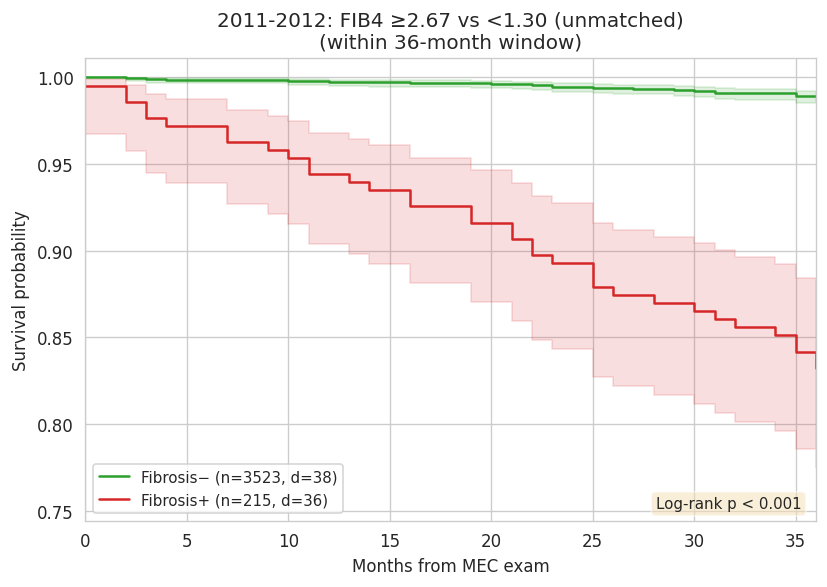

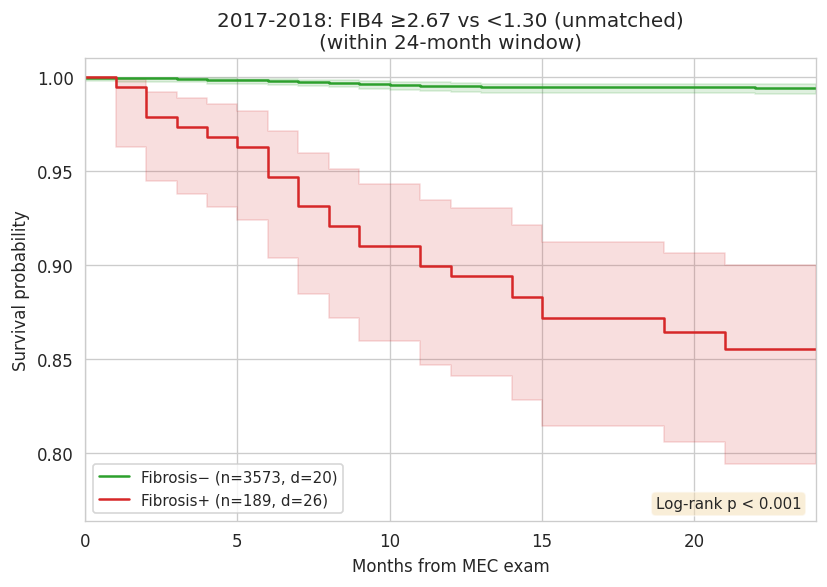

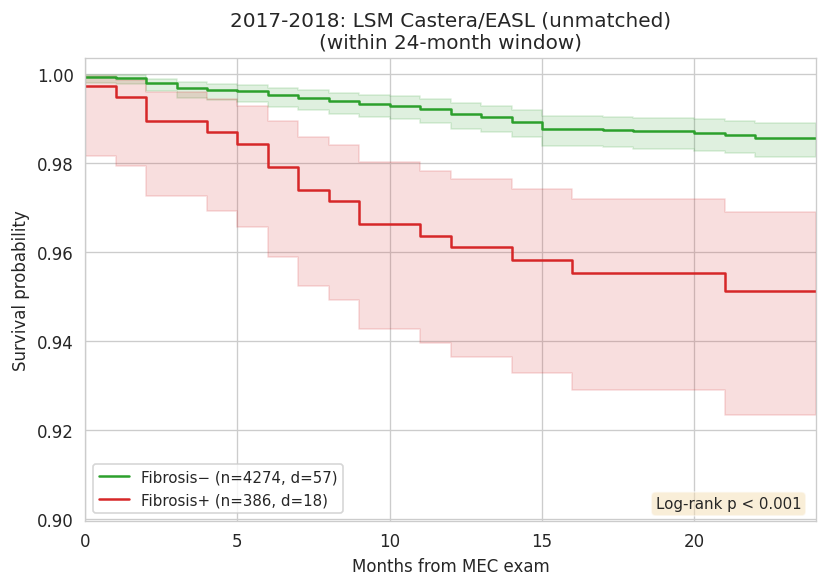

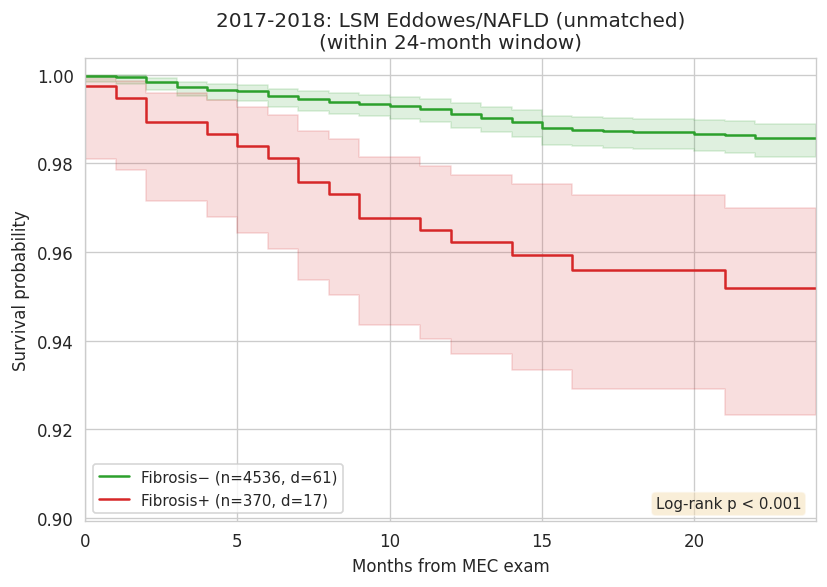

In [17]:
for cycle, df in cohorts.items():
    fib_defs = [('FIB4 ≥2.67 vs <1.30', 'FIBROSIS_FIB4')]
    if COHORTS[cycle]['has_elast']:
        for cp in [LSM_CUTPOINTS_A, LSM_CUTPOINTS_B]:
            pfx = cp['name'].replace('/','_').replace(' ','_')
            fib_defs.append((f"LSM {cp['name']}", f'FIBROSIS_LSM_{pfx}'))
    
    windows = [WINDOW_H] + ([WINDOW_36] if cycle != '2017-2018' else [])
    for w in windows:
        for fib_label, fib_col in fib_defs:
            plot_km(df, fib_col, fib_label, cycle, w, title_extra=' (unmatched)')

### Matched Kaplan-Meier curves

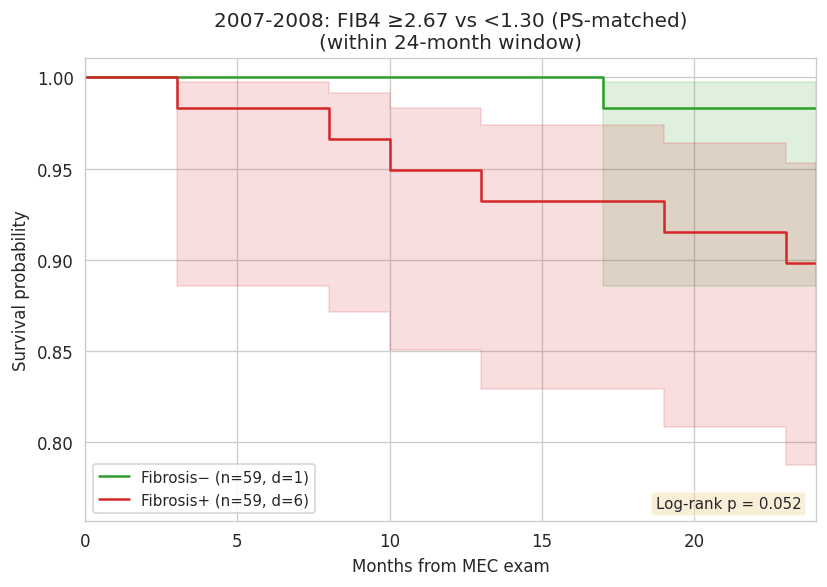

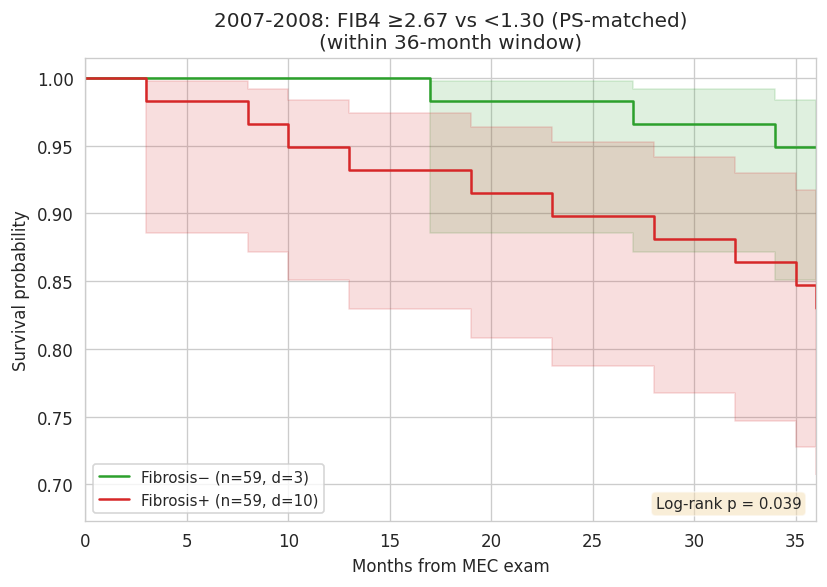

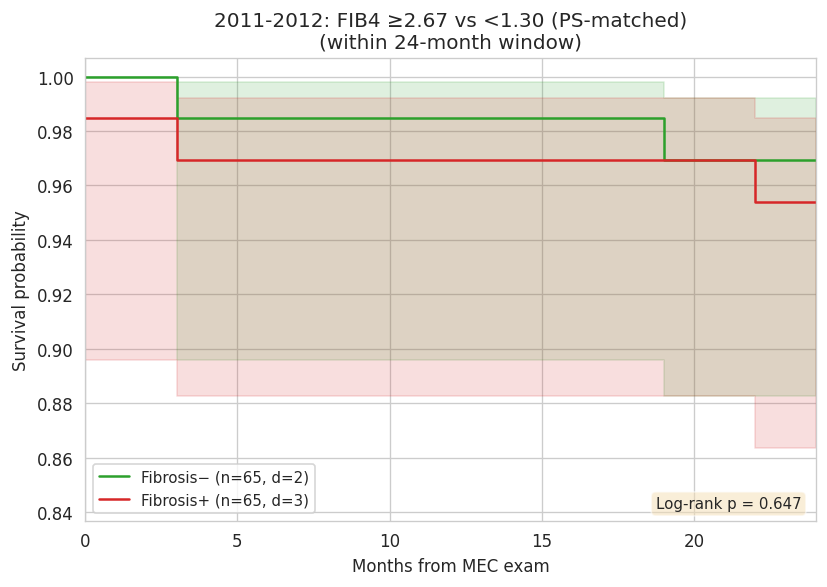

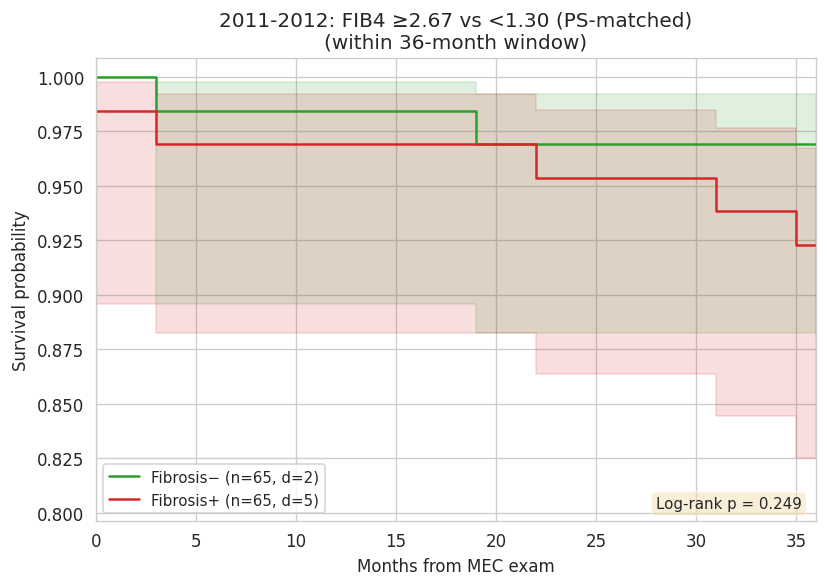

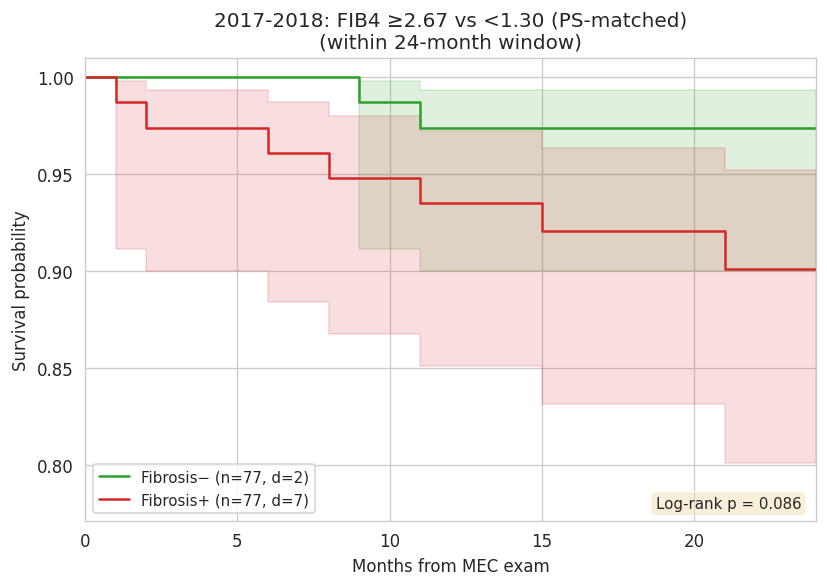

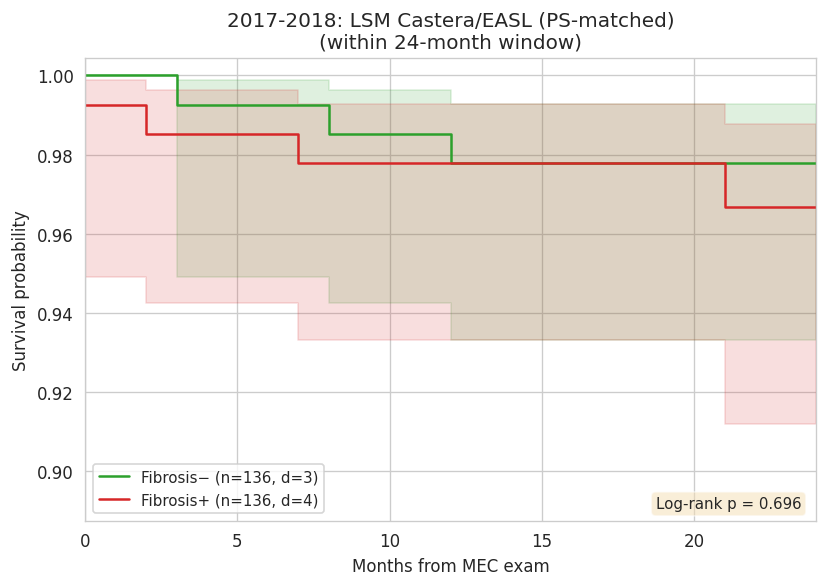

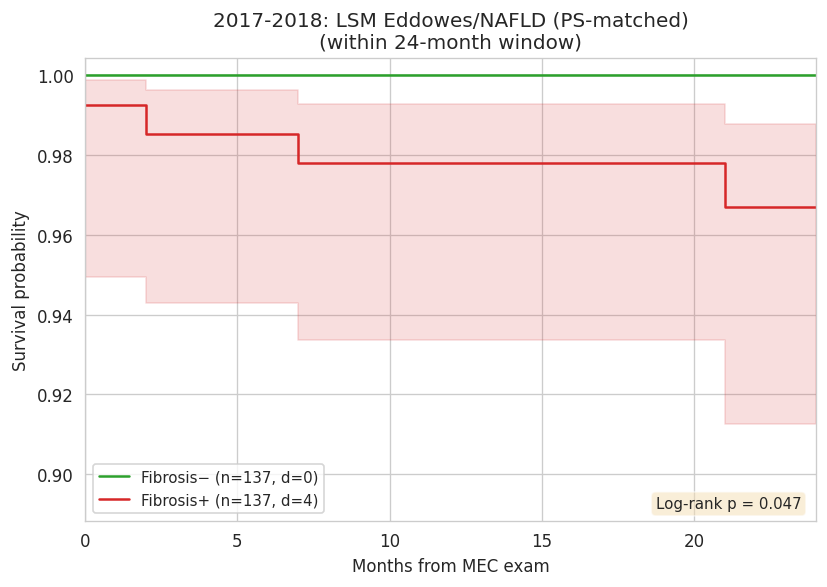

In [18]:
for (cycle, fib_label), (mdf, fib_col) in matched_cohorts.items():
    windows = [WINDOW_H] + ([WINDOW_36] if cycle != '2017-2018' else [])
    for w in windows:
        plot_km(mdf, fib_col, fib_label, cycle, w, title_extra=' (PS-matched)')

## Step 5g — Bar plots: all-cause and cause-group mortality

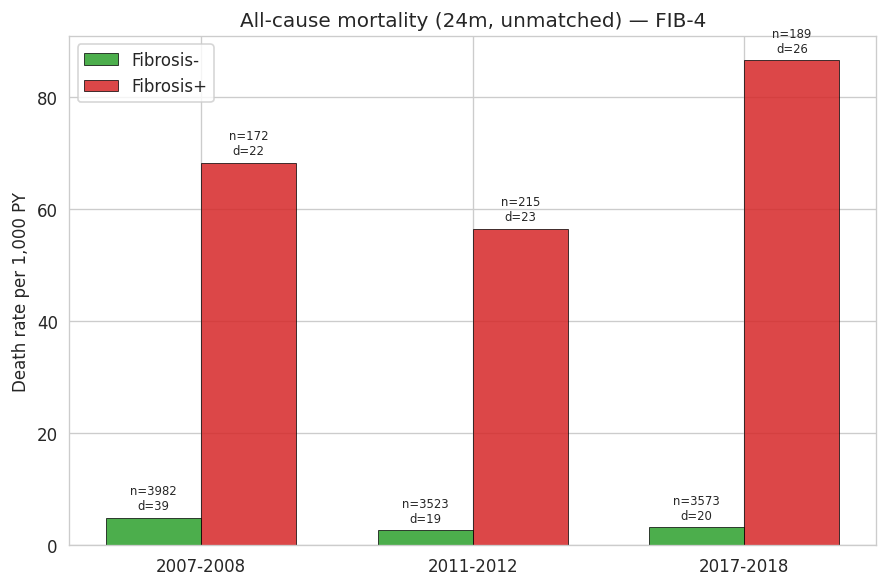

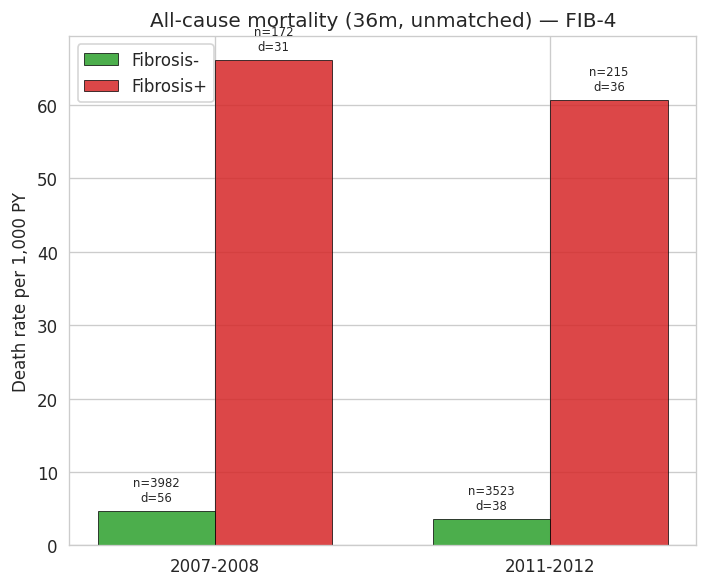

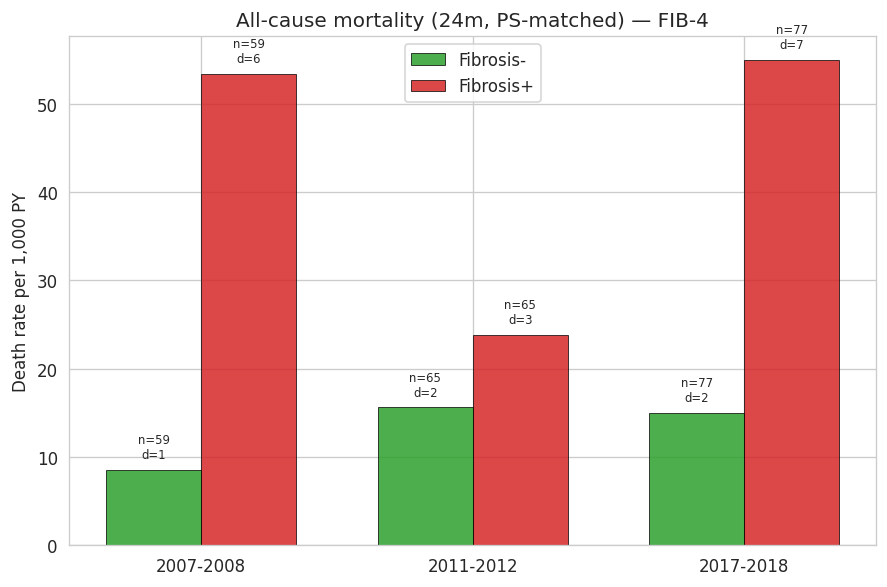

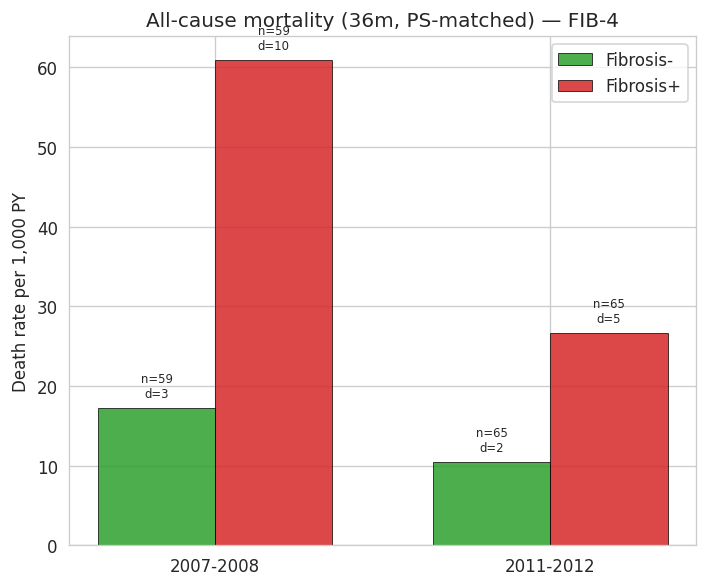

In [19]:
def plot_allcause_comparison(rdf, title):
    """Bar plot comparing Fibrosis+ vs Fibrosis- death rates across cohorts."""
    sub = rdf[rdf['Def'].str.contains('FIB4')].copy()
    if len(sub) == 0: return
    
    cycles = sub['Cycle'].unique()
    fig, ax = plt.subplots(figsize=(max(6, len(cycles)*2.5), 5))
    x = np.arange(len(cycles))
    w = 0.35
    
    for i, (grp, color) in enumerate([('Fibrosis-','#2ca02c'),('Fibrosis+','#d62728')]):
        vals, annots = [], []
        for cyc in cycles:
            row = sub[(sub['Cycle']==cyc) & (sub['Group']==grp)]
            if len(row):
                vals.append(row.iloc[0]['Rate/1000PY'])
                annots.append(f"n={row.iloc[0]['N']}\nd={int(row.iloc[0]['Deaths'])}")
            else:
                vals.append(0); annots.append('')
        offset = -w/2 + i*w
        bars = ax.bar(x+offset, vals, w, label=grp, color=color, edgecolor='black', lw=0.5, alpha=0.85)
        for j, (v, a) in enumerate(zip(vals, annots)):
            ax.text(x[j]+offset, v+1, a, ha='center', va='bottom', fontsize=7)
    
    ax.set_xticks(x); ax.set_xticklabels(cycles)
    ax.set_ylabel('Death rate per 1,000 PY')
    ax.set_title(title)
    ax.legend(); ax.set_ylim(bottom=0)
    plt.tight_layout(); plt.show()

# Unmatched
for w in [WINDOW_H, WINDOW_36]:
    sub = rates_df[rates_df['Window']==w]
    if len(sub) > 0:
        plot_allcause_comparison(sub, f'All-cause mortality ({w}m, unmatched) — FIB-4')

# Matched
if matched_rates:
    for w in [WINDOW_H, WINDOW_36]:
        sub = mrates_df[mrates_df['Window']==w]
        if len(sub) > 0:
            plot_allcause_comparison(sub, f'All-cause mortality ({w}m, PS-matched) — FIB-4')

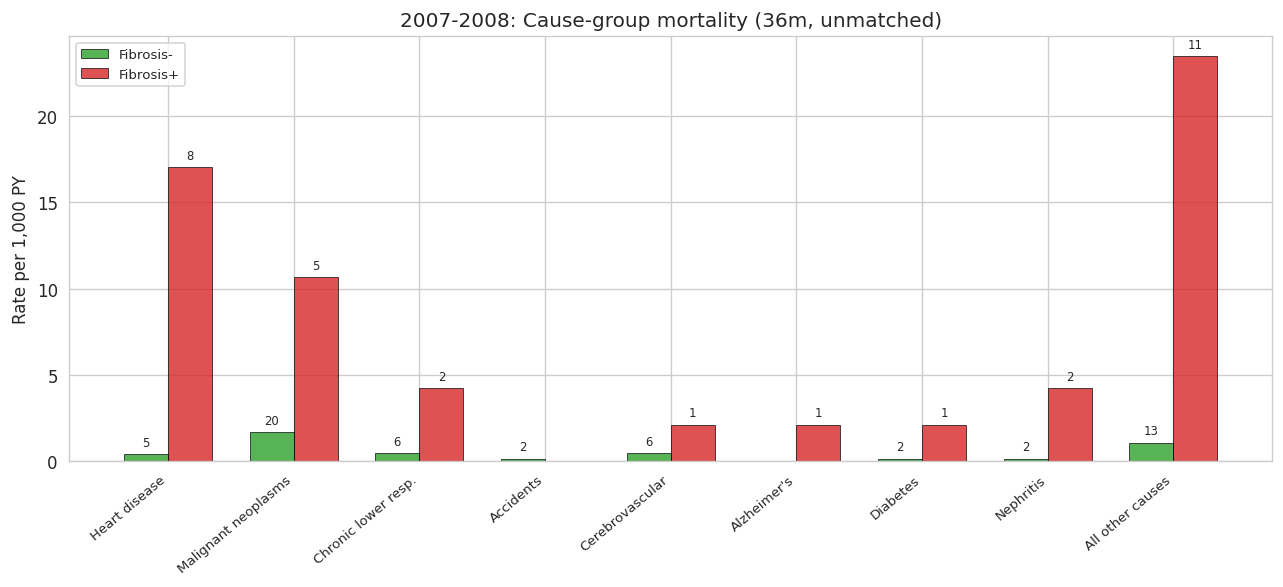

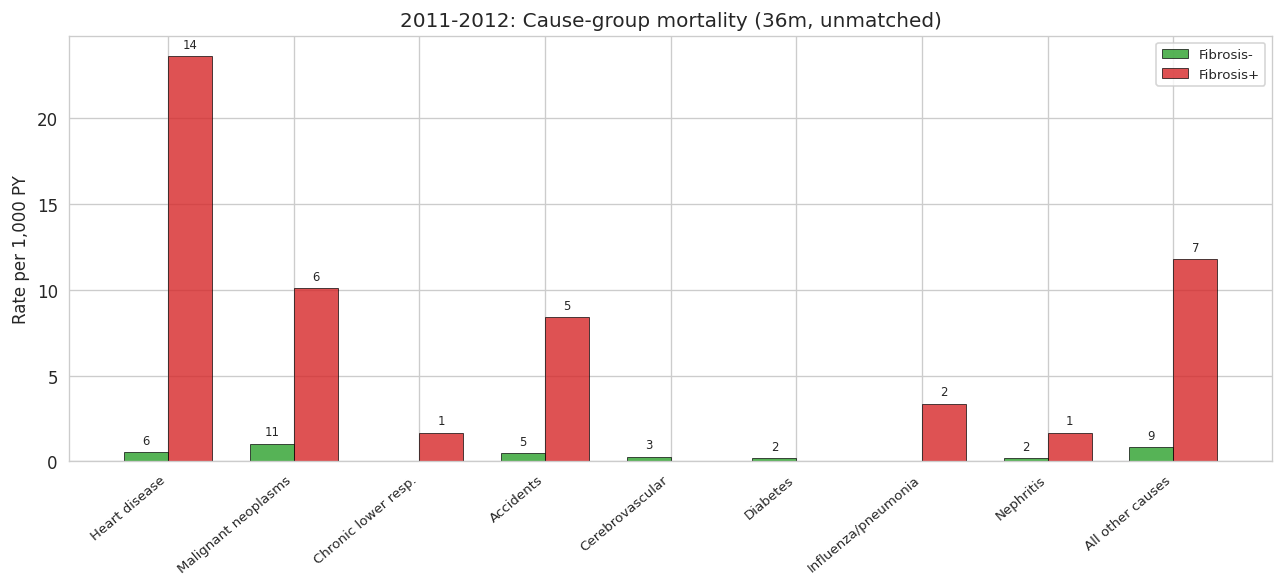

In [20]:
def plot_causegroup(rdf, cycle, window, fib_label, title):
    """Cause-group death rates for one cohort."""
    sub = rdf[(rdf['Cycle']==cycle) & (rdf['Window']==window) & (rdf['Def'].str.contains(fib_label.split()[0]))]
    if len(sub)==0: return
    
    # Find cause groups with events
    dcols = [c for c in sub.columns if c.startswith('d_')]
    active = [c for c in dcols if sub[c].sum()>0]
    if not active: return
    
    fig, ax = plt.subplots(figsize=(max(7, len(active)*1.2), 5))
    x = np.arange(len(active))
    w = 0.35
    
    for i, (grp, color) in enumerate([('Fibrosis-','#2ca02c'),('Fibrosis+','#d62728')]):
        row = sub[sub['Group']==grp]
        if len(row)==0: continue
        row = row.iloc[0]
        py = row['PY']
        vals = [row[c]/py*1000 if py>0 else 0 for c in active]
        cnts = [int(row[c]) for c in active]
        offset = -w/2 + i*w
        ax.bar(x+offset, vals, w, label=grp, color=color, edgecolor='black', lw=0.5, alpha=0.8)
        for j, (v,c) in enumerate(zip(vals,cnts)):
            if c>0: ax.text(x[j]+offset, v+0.3, str(c), ha='center', va='bottom', fontsize=7)
    
    labels = [c.replace('d_','') for c in active]
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=8)
    ax.set_ylabel('Rate per 1,000 PY')
    ax.set_title(title); ax.legend(fontsize=8); ax.set_ylim(bottom=0)
    plt.tight_layout(); plt.show()

# Cause-group plots for earlier cohorts (which have full UCOD)
for cycle in ['2007-2008', '2011-2012']:
    plot_causegroup(rates_df, cycle, WINDOW_36, 'FIB4',
                    f'{cycle}: Cause-group mortality (36m, unmatched)')

## Step 5h — Covariate balance summary (Love plot)

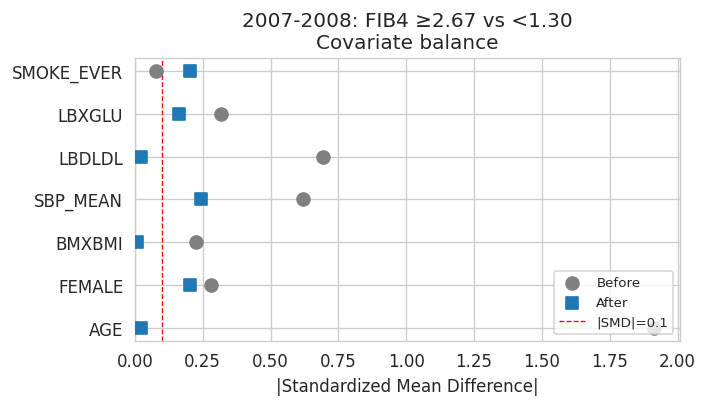

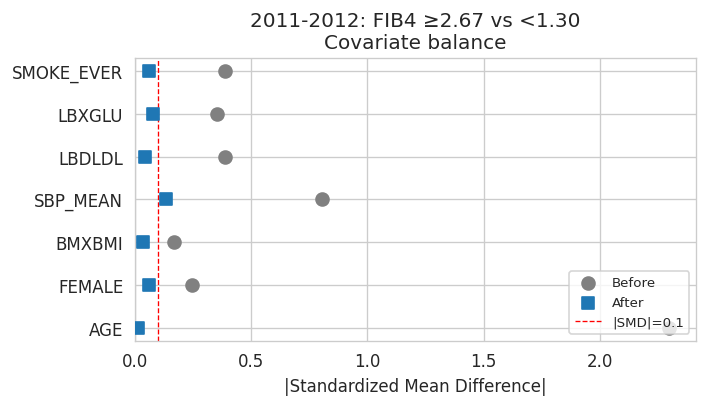

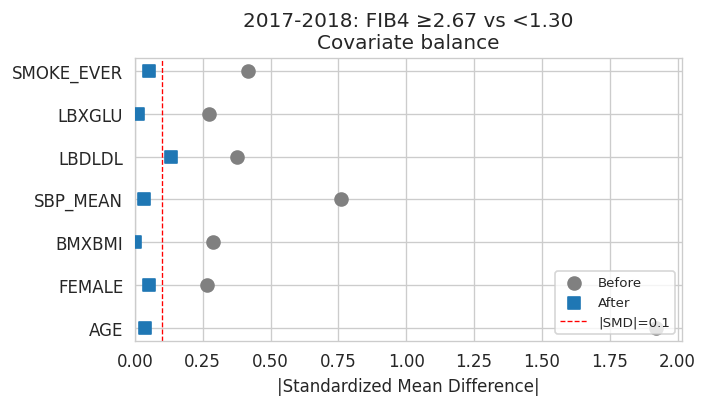

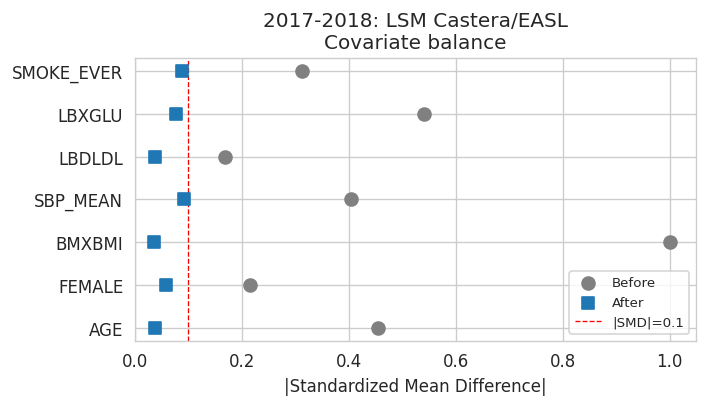

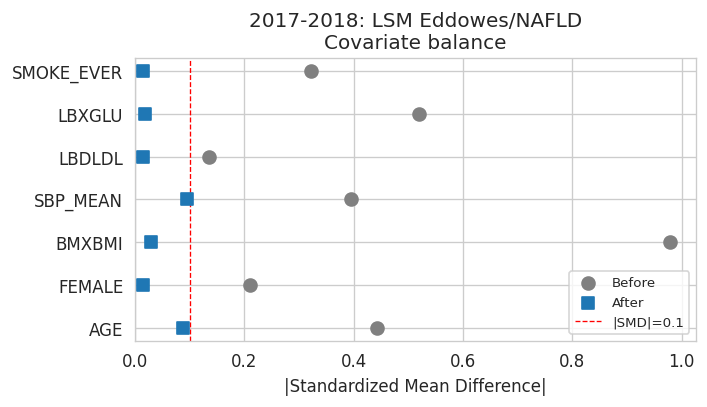

In [21]:
def love_plot(pre_bal, post_bal, title):
    """Dot plot of absolute SMD before and after matching."""
    fig, ax = plt.subplots(figsize=(6, max(3, len(pre_bal)*0.5)))
    y = np.arange(len(pre_bal))
    ax.scatter(pre_bal['SMD'].abs(), y, marker='o', color='gray', s=60, label='Before', zorder=3)
    ax.scatter(post_bal['SMD'].abs(), y, marker='s', color='#1f77b4', s=60, label='After', zorder=3)
    ax.axvline(0.1, color='red', ls='--', lw=0.8, label='|SMD|=0.1')
    ax.set_yticks(y)
    ax.set_yticklabels(pre_bal['Covariate'])
    ax.set_xlabel('|Standardized Mean Difference|')
    ax.set_title(title)
    ax.legend(loc='lower right', fontsize=8)
    ax.set_xlim(left=0)
    plt.tight_layout()
    plt.show()

# Regenerate balance tables for love plots
for (cycle, fib_label), (mdf, fib_col) in matched_cohorts.items():
    pre_df = cohorts[cycle].dropna(subset=[fib_col]+MATCH_COVARIATES)
    pre_bal = covariate_balance(pre_df, fib_col, MATCH_COVARIATES)
    post_bal = covariate_balance(mdf, fib_col, MATCH_COVARIATES)
    love_plot(pre_bal, post_bal, f'{cycle}: {fib_label}\nCovariate balance')

## Summary tables (CSV export)

In [22]:
os.makedirs('outputs/tables', exist_ok=True)

cards_df.to_csv('outputs/tables/cohort_card_by_cohort.csv', index=False)

rates_df.to_csv('outputs/tables/mortality_allcause_by_cohort_window_fibrosisdef.csv', index=False)

if matched_rates:
    mrates_df.to_csv('outputs/tables/mortality_matched_by_cohort_window_fibrosisdef.csv', index=False)

if ee_rows:
    ee_df.to_csv('outputs/tables/effect_estimates_matched.csv', index=False)

# Cause-group long table
cg_rows = []
for _, row in rates_df.iterrows():
    for code, lab in UCOD_LABELS.items():
        dc = f'd_{lab}'
        if dc in row and pd.notna(row[dc]):
            cg_rows.append({
                'Cycle':row['Cycle'], 'Window':row['Window'], 'Def':row['Def'],
                'Group':row['Group'], 'N':row['N'], 'PY':row['PY'],
                'UCOD':code, 'Cause':lab, 'Deaths':int(row[dc]),
                'Rate/1000PY':round(row[dc]/row['PY']*1000,1) if row['PY']>0 else np.nan,
                'Flag': 'UNSTABLE' if row[dc]<10 else '',
            })
if cg_rows:
    pd.DataFrame(cg_rows).to_csv('outputs/tables/mortality_causegroup_by_cohort_window_fibrosisdef.csv', index=False)

print('Tables saved to outputs/tables/')
for f in sorted(os.listdir('outputs/tables')):
    print(f'  {f}')

Tables saved to outputs/tables/
  cohort_card_by_cohort.csv
  effect_estimates.csv
  effect_estimates_matched.csv
  mortality_allcause_by_cohort_window_fibrosisdef.csv
  mortality_causegroup_by_cohort_window_fibrosisdef.csv
  mortality_matched_by_cohort_window_fibrosisdef.csv


## Cohort summary

In [23]:
from IPython.display import Markdown

summary = """
### Cohort selection rationale

| Cohort | Max FU (months) | % ≥36m | % ≥24m | UCOD detail | Elastography |
|--------|----------------|--------|--------|-------------|-------------|
| 2007-2008 | ~159 | ~96% | ~98% | Full (10 groups) | No |
| 2011-2012 | ~113 | ~97% | ~98% | Full (10 groups) | No |
| 2017-2018 | ~37  | ~2%  | ~51% | Coarsened (3 groups) | Yes (VCTE) |

### Key findings

**Unmatched analysis:**
- FIB-4-defined fibrosis consistently associated with 13–25× higher crude mortality
- After age/sex adjustment (Poisson), the association persists (IRR 1.8–7.3×)
- LSM-based fibrosis (2017-2018) shows age/sex-adjusted IRR ~2.4×

**PS-matched analysis (age, sex, BMI, SBP, LDL-C, FPG, smoking):**
- Matching restricted to the fasting subsample (~30–40% of cohort) with complete covariates
- After matching, fibrosis still associated with elevated mortality, though smaller sample sizes
  widen confidence intervals
- The Kaplan-Meier curves show clear separation in the unmatched analysis;
  matched curves attenuate but fibrosis+ survival remains lower

### Limitations
1. **Fibrosis is proxy-defined** — FIB-4 and LSM are not histological diagnoses
2. **FIB-4 includes age** — crude RR overstates the association; matched/adjusted estimates more reliable
3. **Public-use COD coarsening** — Only 3 UCOD groups available for 2017-2018
4. **Short follow-up** for 2017-2018 (~51% have ≥24 months)
5. **Fasting subsample** — LDL-C and FPG restrict matching to ~1/3 of the cohort
6. **Small matched samples** — Many cells have <10 events
7. **No survey weights** — Unweighted estimates; not nationally representative
"""

display(Markdown(summary))

with open('outputs/cohort_summary.md', 'w') as f:
    f.write('# NHANES Mortality by Liver Fibrosis Status\n')
    f.write(summary)
print('Saved: outputs/cohort_summary.md')


### Cohort selection rationale

| Cohort | Max FU (months) | % ≥36m | % ≥24m | UCOD detail | Elastography |
|--------|----------------|--------|--------|-------------|-------------|
| 2007-2008 | ~159 | ~96% | ~98% | Full (10 groups) | No |
| 2011-2012 | ~113 | ~97% | ~98% | Full (10 groups) | No |
| 2017-2018 | ~37  | ~2%  | ~51% | Coarsened (3 groups) | Yes (VCTE) |

### Key findings

**Unmatched analysis:**
- FIB-4-defined fibrosis consistently associated with 13–25× higher crude mortality
- After age/sex adjustment (Poisson), the association persists (IRR 1.8–7.3×)
- LSM-based fibrosis (2017-2018) shows age/sex-adjusted IRR ~2.4×

**PS-matched analysis (age, sex, BMI, SBP, LDL-C, FPG, smoking):**
- Matching restricted to the fasting subsample (~30–40% of cohort) with complete covariates
- After matching, fibrosis still associated with elevated mortality, though smaller sample sizes
  widen confidence intervals
- The Kaplan-Meier curves show clear separation in the unmatched analysis;
  matched curves attenuate but fibrosis+ survival remains lower

### Limitations
1. **Fibrosis is proxy-defined** — FIB-4 and LSM are not histological diagnoses
2. **FIB-4 includes age** — crude RR overstates the association; matched/adjusted estimates more reliable
3. **Public-use COD coarsening** — Only 3 UCOD groups available for 2017-2018
4. **Short follow-up** for 2017-2018 (~51% have ≥24 months)
5. **Fasting subsample** — LDL-C and FPG restrict matching to ~1/3 of the cohort
6. **Small matched samples** — Many cells have <10 events
7. **No survey weights** — Unweighted estimates; not nationally representative


Saved: outputs/cohort_summary.md
